# Advanced Analysis - Optional Tasks

This notebook includes advanced analysis tasks:
- K-means clustering of LSOAs based on deprivation patterns
- Comparison with neighboring local authorities
- Additional statistical insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os

OUTPUT_FOLDER = 'output'
INPUT_FILE = 'File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv'
LOCAL_AUTHORITY = 'Leeds'
NEIGHBORING_LAs = ['Bradford', 'Wakefield', 'Kirklees', 'Calderdale']  # Neighboring authorities

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("=" * 60)
print("ADVANCED ANALYSIS")
print("=" * 60)

ADVANCED ANALYSIS


## Load Full Dataset for Comparison

In [2]:
# Load full dataset
print(f"Loading full dataset from {INPUT_FILE}...")

encodings = ['utf-8', 'latin-1', 'cp1252']
df_full = None

for encoding in encodings:
    try:
        df_full = pd.read_csv(INPUT_FILE, encoding=encoding, low_memory=False)
        print(f"Successfully loaded with {encoding} encoding")
        break
    except (UnicodeDecodeError, FileNotFoundError):
        continue

if df_full is None:
    raise FileNotFoundError(f"Could not load {INPUT_FILE}")

print(f"Full dataset shape: {df_full.shape}")

# Load Leeds data
leeds_file = os.path.join(OUTPUT_FOLDER, 'Leeds_IMD_with_Health.csv')
if os.path.exists(leeds_file):
    df_leeds = pd.read_csv(leeds_file)
    print(f"Leeds data loaded: {len(df_leeds)} rows")
else:
    print("Leeds data not found. Filtering from full dataset...")
    # Filter for Leeds
    la_col = None
    for name in ['Local Authority District name (2019)', 'Local Authority', 'LA name', 'LAD19NM']:
        if name in df_full.columns:
            la_col = name
            break
    
    if la_col:
        df_leeds = df_full[df_full[la_col].str.contains(LOCAL_AUTHORITY, case=False, na=False)].copy()
        print(f"Filtered Leeds data: {len(df_leeds)} rows")
    else:
        raise ValueError("Could not find Local Authority column")

Loading full dataset from File_7_-_All_IoD2019_Scores__Ranks__Deciles_and_Population_Denominators_3.csv...
Successfully loaded with utf-8 encoding
Full dataset shape: (32844, 57)
Leeds data loaded: 482 rows


## Task 1: K-Means Clustering of LSOAs


K-MEANS CLUSTERING


C:\Users\Rhiya Raman\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



Clustered 482 LSOAs into 4 clusters

Cluster distribution:
Cluster
0    121
1    100
2    133
3    128
Name: count, dtype: int64

Cluster Characteristics (mean scores):
         Income Score (rate)  Employment Score (rate)  \
Cluster                                                 
0                   0.309298                 0.222826   
1                   0.052250                 0.049200   
2                   0.063218                 0.058023   
3                   0.143586                 0.109000   

         Education, Skills and Training Score  \
Cluster                                         
0                                   59.448554   
1                                    8.242980   
2                                    7.908000   
3                                   27.976492   

         Health Deprivation and Disability Score  Crime Score  \
Cluster                                                         
0                                       1.265926     1.591785 

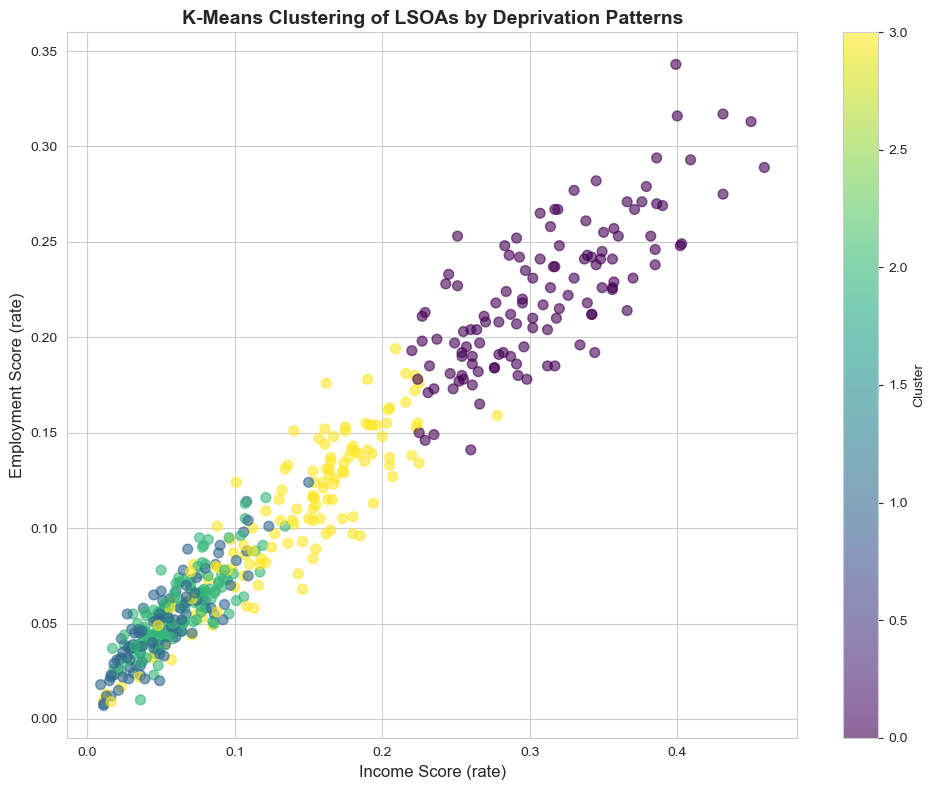


Clustering visualization saved to output\kmeans_clustering.png
Clustered data saved to output\Leeds_IMD_Clustered.csv


In [3]:
print("\n" + "=" * 60)
print("K-MEANS CLUSTERING")
print("=" * 60)

# Find domain score columns
domain_names = ['Income', 'Employment', 'Education', 'Health', 'Crime', 'Housing', 'Environment']
domain_cols = []

for domain in domain_names:
    matching_cols = [col for col in df_leeds.columns 
                    if domain.lower() in col.lower() and 'score' in col.lower()]
    if matching_cols:
        domain_cols.append(matching_cols[0])

if len(domain_cols) < 2:
    print("Warning: Not enough domain columns found for clustering")
else:
    # Prepare data for clustering
    cluster_data = df_leeds[domain_cols].dropna()
    
    if len(cluster_data) < 5:
        print("Warning: Insufficient data for clustering")
    else:
        # Standardize features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(cluster_data)
        
        # Perform k-means clustering (try different numbers of clusters)
        n_clusters = 4  # You can adjust this
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X_scaled)
        
        # Add cluster labels to dataframe
        df_leeds_clustered = df_leeds.loc[cluster_data.index].copy()
        df_leeds_clustered['Cluster'] = cluster_labels
        
        print(f"\nClustered {len(df_leeds_clustered)} LSOAs into {n_clusters} clusters")
        print("\nCluster distribution:")
        print(df_leeds_clustered['Cluster'].value_counts().sort_index())
        
        # Analyze cluster characteristics
        print("\nCluster Characteristics (mean scores):")
        cluster_summary = df_leeds_clustered.groupby('Cluster')[domain_cols].mean()
        print(cluster_summary)
        
        # Visualize clusters
        if len(domain_cols) >= 2:
            fig, ax = plt.subplots(figsize=(10, 8))
            scatter = ax.scatter(df_leeds_clustered[domain_cols[0]], 
                               df_leeds_clustered[domain_cols[1]],
                               c=df_leeds_clustered['Cluster'], 
                               cmap='viridis', s=50, alpha=0.6)
            ax.set_xlabel(domain_cols[0], fontsize=12)
            ax.set_ylabel(domain_cols[1], fontsize=12)
            ax.set_title('K-Means Clustering of LSOAs by Deprivation Patterns', fontsize=14, fontweight='bold')
            plt.colorbar(scatter, ax=ax, label='Cluster')
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_FOLDER, 'kmeans_clustering.png'), dpi=300, bbox_inches='tight')
            plt.show()
            print(f"\nClustering visualization saved to {os.path.join(OUTPUT_FOLDER, 'kmeans_clustering.png')}")
        
        # Save clustered data
        output_path = os.path.join(OUTPUT_FOLDER, 'Leeds_IMD_Clustered.csv')
        df_leeds_clustered.to_csv(output_path, index=False)
        print(f"Clustered data saved to {output_path}")

## Task 2: Compare Leeds with Neighboring Authorities


COMPARISON WITH NEIGHBORING AUTHORITIES

Comparison of Local Authorities:
Local Authority  Number of LSOAs  Mean IMD Score  Median IMD Score  Min IMD Score  Max IMD Score   Std Dev
       Bradford              310       33.889119           32.0865          2.593         75.905 19.148039
          Leeds              482       27.243361           20.0255          2.022         78.577 19.336698
      Wakefield              209       27.239373           24.7760          4.317         71.126 15.402081
     Calderdale              128       26.734281           22.4190          2.512         71.544 15.934551
       Kirklees              259       24.868089           22.0010          3.900         63.016 14.476722


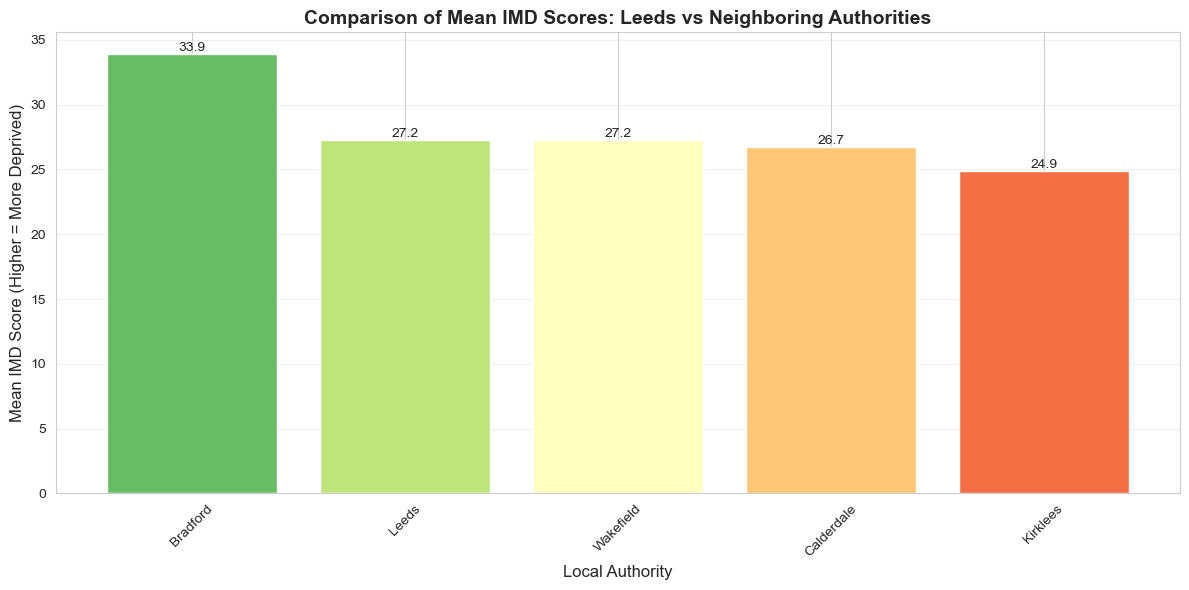


Comparison chart saved to output\la_comparison.png
Comparison data saved to output\la_comparison.csv


In [4]:
print("\n" + "=" * 60)
print("COMPARISON WITH NEIGHBORING AUTHORITIES")
print("=" * 60)

# Find Local Authority column
la_col = None
for name in ['Local Authority District name (2019)', 'Local Authority', 'LA name', 'LAD19NM']:
    if name in df_full.columns:
        la_col = name
        break

if la_col is None:
    print("Warning: Could not find Local Authority column")
else:
    # Find IMD score column
    imd_score_col = None
    for col in df_full.columns:
        if 'imd' in col.lower() and 'score' in col.lower():
            imd_score_col = col
            break
    
    if imd_score_col:
        # Filter for Leeds and neighboring authorities
        comparison_las = [LOCAL_AUTHORITY] + NEIGHBORING_LAs
        
        comparison_data = []
        
        for la in comparison_las:
            la_data = df_full[df_full[la_col].str.contains(la, case=False, na=False)]
            if len(la_data) > 0:
                imd_scores = la_data[imd_score_col].dropna()
                if len(imd_scores) > 0:
                    comparison_data.append({
                        'Local Authority': la,
                        'Number of LSOAs': len(la_data),
                        'Mean IMD Score': imd_scores.mean(),
                        'Median IMD Score': imd_scores.median(),
                        'Min IMD Score': imd_scores.min(),
                        'Max IMD Score': imd_scores.max(),
                        'Std Dev': imd_scores.std()
                    })
        
        if comparison_data:
            comparison_df = pd.DataFrame(comparison_data)
            comparison_df = comparison_df.sort_values('Mean IMD Score', ascending=False)
            
            print("\nComparison of Local Authorities:")
            print(comparison_df.to_string(index=False))
            
            # Visualize comparison
            fig, ax = plt.subplots(figsize=(12, 6))
            bars = ax.bar(comparison_df['Local Authority'], comparison_df['Mean IMD Score'],
                         color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(comparison_df))))
            ax.set_xlabel('Local Authority', fontsize=12)
            ax.set_ylabel('Mean IMD Score (Higher = More Deprived)', fontsize=12)
            ax.set_title('Comparison of Mean IMD Scores: Leeds vs Neighboring Authorities', 
                        fontsize=14, fontweight='bold')
            ax.tick_params(axis='x', rotation=45)
            ax.grid(axis='y', alpha=0.3)
            
            # Add value labels
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.1f}', ha='center', va='bottom')
            
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_FOLDER, 'la_comparison.png'), dpi=300, bbox_inches='tight')
            plt.show()
            print(f"\nComparison chart saved to {os.path.join(OUTPUT_FOLDER, 'la_comparison.png')}")
            
            # Save comparison data
            comparison_df.to_csv(os.path.join(OUTPUT_FOLDER, 'la_comparison.csv'), index=False)
            print(f"Comparison data saved to {os.path.join(OUTPUT_FOLDER, 'la_comparison.csv')}")
        else:
            print("No data found for comparison authorities")

## Summary

In [5]:
print("\n" + "=" * 60)
print("ADVANCED ANALYSIS COMPLETE")
print("=" * 60)
print("\nAdvanced analysis outputs saved to 'output' folder:")
print("  • K-means clustering results")
print("  • Comparison with neighboring authorities")
print("  • Clustered dataset")


ADVANCED ANALYSIS COMPLETE

Advanced analysis outputs saved to 'output' folder:
  • K-means clustering results
  • Comparison with neighboring authorities
  • Clustered dataset
